In [12]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.experiments import CompareModels, ModelEvaluator,Experiment
from utils.plot_function import *
from scripts.modelClassGPU import ConfiModel
#from scripts.modelClassGPU_old import ConfiModel as old_model
#from scripts.experiments import Experiment 

## aggregate data specifically on this cases

In [2]:
#help function
sub_lst_all = [2, 3, 5, 6 ,11 ,15 ,20, 25]
fit_res_path = 'P:/3026008.02/fit_res/'
exp_name = 'split_data'
def organize_parial_data(m_id:int):
    # make a folder to store the aggregated data
    full_file_path = os.path.join(fit_res_path, exp_name, 'full', 'model_' + str(m_id))
    os.makedirs(full_file_path, exist_ok=True)
    part_path = os.path.join(fit_res_path, exp_name, 'partial', 'model_' + str(m_id))

    for sub_id in sub_lst_all:
        print(f"\n ------- Start Aggregating for Subject {sub_id} ---------- ")
        sub_path = os.path.join(part_path, 'subject_' + str(sub_id))
        all_files = [f.path for f in os.scandir(sub_path) if f.is_file() and f.path.endswith('.pkl')]

        if os.path.isdir(sub_path) and all_files:
            files_by_visrel1 = [f for f in all_files if f.split('_')[10][-1]=='1']
            files_by_visrel2 = [f for f in all_files if f.split('_')[10][-1]=='2']
            #print(files_by_visrel1)
            for vrel, files in zip([1,2], [files_by_visrel1, files_by_visrel2]):
                df_full = []
                for f in files:
                    df_part = pd.read_pickle(f)
                    df_full.append(df_part)
                df_full = pd.concat(df_full, ignore_index=True)
                df_full.to_pickle(os.path.join(full_file_path, 'fitted_model_' + str(m_id) +  '_subject_' + str(sub_id) + '_vrel' + str(vrel) + '.pkl'))
        else:
            raise RuntimeError(f"Folder '{sub_path}' does not exist or has no files")

In [ ]:
#organize_parial_data(m_id=1)


 ------- Start Aggregating for Subject 2 ---------- 
['P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_2\\fitted_sub_2_m1_bads_f0_vrel1_XYAhwU.pkl', 'P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_2\\fitted_sub_2_m1_bads_f0_vrel1_aTBGVX.pkl', 'P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_2\\fitted_sub_2_m1_bads_f0_vrel1_lvOYQb.pkl', 'P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_2\\fitted_sub_2_m1_bads_f0_vrel1_utCiwo.pkl', 'P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_2\\fitted_sub_2_m1_bads_f0_vrel1_MCnqTJ.pkl']

 ------- Start Aggregating for Subject 3 ---------- 
['P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_3\\fitted_sub_3_m1_bads_f0_vrel1_KlRySE.pkl', 'P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_3\\fitted_sub_3_m1_bads_f0_vrel1_MmkShI.pkl', 'P:/3026008.02/fit_res/split_data\\partial\\model_1\\subject_3\\fitted_sub_3_m1_bads_f0_vrel1_mRqrYE.pkl', 'P:/3026008.02/fit_res/split_data\

In [3]:
def get_sub_fit_data(m_id:int, sub_id:int, vrel:int):
    sub_file_name = os.path.join(fit_res_path, exp_name, 'full', 'model_' + str(m_id), 'fitted_model_' + str(m_id) +  '_subject_' + str(sub_id) + '_vrel' + str(vrel) + '.pkl')
    df = pd.read_pickle(sub_file_name)
    df.loc[ : ,'vrel'] = vrel
    return df

In [5]:
df = get_sub_fit_data(m_id=1, sub_id=2, vrel=1)
df

,run_id,model_id,sub_id,nfold,train_nll,est_params,init_params,runtime,success,vrel
0,20251108_213227,1,2,0,9473.985641,"[1.7509365677833557, 8.496075719594955, 0.0241...","[6.252847239755117, 3.252297909306914, 4.22208...",10.138834,True,1
1,20251108_214344,1,2,0,9381.850490,"[1.1640107780694962, 7.559727024286985, 1.7016...","[8.0517461270342, 6.488788198435418, 10.123454...",11.279859,True,1
2,20251108_213440,1,2,0,9459.787596,"[1.5747592449188232, 7.64049319177866, 0.84100...","[6.288505586155488, 7.359432416134318, 15.8886...",14.366518,True,1
3,20251108_215147,1,2,0,9469.507587,"[1.520111083984375, 9.068295001983643, 0.00552...","[8.868249205354369, 12.91402706066907, 10.8714...",17.120793,True,1
4,20251108_214233,1,2,0,9340.283928,"[1.4855382144451141, 7.167923158034682, 4.6017...","[9.085983173048316, 8.897047404311241, 5.53333...",20.191071,True,1
5,20251108_215230,1,2,0,9426.012280,"[1.5587871074676514, 7.136767208576202, 0.9581...","[3.580173332794822, 5.682586238743126, 16.9422...",9.954104,True,1
6,20251108_214535,1,2,0,9417.628338,"[1.43340003490448, 7.310501778498292, 2.130151...","[5.606388906833474, 6.802437000324344, 18.8381...",23.225492,True,1
7,20251108_215928,1,2,0,9716.435748,"[1.6294009685516357, 6.980972230434418, 0.1449...","[6.728177123021085, 11.056370687169025, 0.8841...",13.874340,True,1
8,20251110_103213,1,2,0,9463.123031,"[1.5046467185020447, 6.13221525400877, 0.08882...","[2.694719487935079, 3.4610590143716684, 12.927...",13.530152,True,1
9,20251110_104301,1,2,0,9524.264502,"[1.7944636344909668, 7.296900242567062, 0.9103...","[8.633505929402586, 10.327346187375516, 14.554...",10.789330,True,1


In [4]:
with open(os.path.join(fit_res_path, exp_name, 'partial', 'model_1', 'est_param_names.txt')) as f:
    params_lst = [line.rstrip() for line in f]
#params_lst = np.loadtxt(os.path.join(fit_res_path, exp_name, 'partial', 'model_1', 'est_param_names.txt'))
params_lst

['sig_V',
 'sig_A',
 'kC1',
 'mC1',
 'w_vis',
 'sig_P',
 'p_com',
 'rngA',
 'rngV',
 'sig_rs',
 'sig_rconf',
 'sig_rc']

In [5]:
# organize the estimated parameters 
df_params = pd.DataFrame(columns=['sub_id', 'vrel'] + params_lst)
for sub_id in sub_lst_all:
    for vrel in [1,2]:
        df_sub = get_sub_fit_data(m_id=1, sub_id=sub_id, vrel=vrel)
        df_params_sub = pd.DataFrame(df_sub['est_params'].to_list(), columns=params_lst)
        df_params_sub['sub_id'] = df_sub['sub_id']
        df_params_sub['vrel'] = df_sub['vrel']
        df_params_sub['train_nll'] = df_sub['train_nll']
        df_params = pd.concat([df_params, df_params_sub], ignore_index=True)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_18288\37410629.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, df_params_sub], ignore_index=True)


In [6]:
df_params.loc[:,'vrelable'] = df_params.vrel.map({1:'High', 2:'Low'})
df_params

,sub_id,vrel,sig_V,sig_A,kC1,mC1,w_vis,sig_P,p_com,rngA,rngV,sig_rs,sig_rconf,sig_rc,train_nll,vrelable
0,2,1,1.750937,8.496076,2.419090e-02,-0.350952,0.000972,8.203316,0.466953,0.298936,0.441732,2.343773e-02,1.331349,0.286577,9473.985641,High
1,2,1,1.164011,7.559727,1.701697e+00,0.769701,0.158810,8.258893,0.465238,0.347783,0.296944,5.519601e-03,1.389272,0.266800,9381.850490,High
2,2,1,1.574759,7.640493,8.410060e-01,0.149308,0.007728,7.886230,0.482314,0.320891,0.255767,3.060300e-03,1.534342,0.281261,9459.787596,High
3,2,1,1.520111,9.068295,5.523315e-03,-0.414753,0.021320,8.229070,0.462853,0.289023,0.523066,1.128467e-04,1.340616,0.284256,9469.507587,High
4,2,1,1.485538,7.167923,4.601735e+00,2.385250,0.010982,7.933565,0.469852,0.332758,0.537855,2.003512e-02,1.397132,0.259310,9340.283928,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,25,1,1.443470,7.820228,7.482166e-01,-1.198877,0.237350,6.334002,0.532736,0.492948,0.610300,2.804163e-02,1.338377,0.427646,8850.939334,High
161,25,2,5.208221,8.114479,4.999956e+01,-9.436455,0.000680,8.319979,0.489012,0.607677,0.717032,6.775620e-06,1.999986,0.558302,9905.645398,Low
162,25,2,6.285366,9.120037,4.926466e-02,-1.079159,0.054376,8.865302,0.489354,0.551768,0.607219,2.362925e-02,1.999577,0.462611,9865.599543,Low
163,25,2,7.676609,13.121418,2.929405e+00,0.973637,0.001690,10.274396,0.508009,0.461958,0.509020,2.572861e-01,1.992045,0.392282,10048.946051,Low


In [7]:
best_idx = df_params.groupby(['sub_id', 'vrel'])['train_nll'].idxmin()
df_best_params = df_params.loc[best_idx, :].reset_index(drop=True)
df_best_params

,sub_id,vrel,sig_V,sig_A,kC1,mC1,w_vis,sig_P,p_com,rngA,rngV,sig_rs,sig_rconf,sig_rc,train_nll,vrelable
0,2,1,1.485538,7.167923,4.601735e+00,2.385250,0.010982,7.933565,0.469852,0.332758,0.537855,2.003512e-02,1.397132,0.259310,9340.283928,High
1,2,2,3.871006,3.960012,7.700840e-02,-0.579953,0.000208,8.949654,0.496454,0.682894,0.735139,6.592396e-03,1.738734,0.269394,8919.832794,Low
2,3,1,2.497768,5.906214,1.100739e-07,-0.950761,0.048367,6.067317,0.633103,0.516712,0.607807,1.000542e-03,1.477241,0.243799,9049.638246,High
3,3,2,8.968356,8.222758,3.638859e-01,-0.094633,0.000197,8.566054,0.489154,0.468094,0.452938,8.620100e-03,1.264201,0.257988,8784.786889,Low
4,5,1,3.309967,4.923712,8.002552e+00,5.388032,0.035164,7.372906,0.494664,0.558630,0.492209,2.615786e-05,1.597318,0.244317,8869.173250,High
5,5,2,3.652709,3.701863,7.558188e-05,0.535812,0.000216,16.484621,0.291894,0.656694,0.603149,2.644071e-02,1.839459,0.333059,9178.675786,Low
6,6,1,1.993579,4.058980,7.320441e-01,-0.015154,0.108437,5.756705,0.504886,0.436691,0.579807,8.548629e-08,1.092539,0.198734,8762.857211,High
7,6,2,1.864438,3.042339,3.196940e+00,2.274374,0.158222,6.705036,0.545042,0.569231,0.528185,3.119697e-04,1.136784,0.194721,8205.002817,Low
8,11,1,1.791069,5.704395,1.578995e+00,0.924734,0.008375,7.163967,0.516600,0.316240,0.175476,7.961252e-04,1.278027,0.234066,9031.203475,High
9,11,2,5.939952,5.587755,5.149377e-01,0.257602,0.018508,10.318820,0.414888,0.425508,0.407985,1.123011e-05,1.103161,0.251638,8836.366168,Low


### compare the parameters of the two visual reliability. 

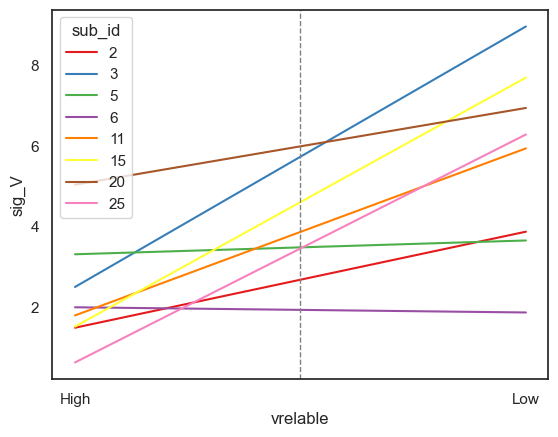

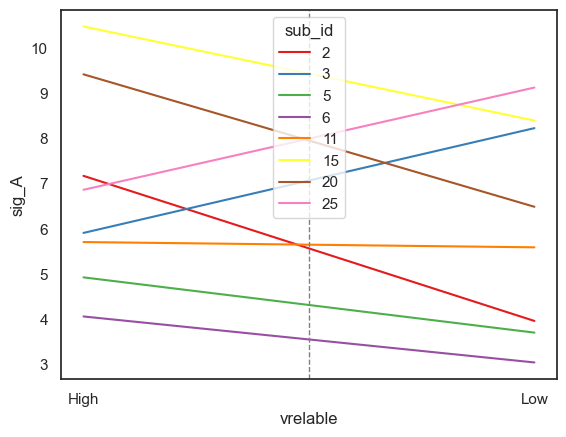

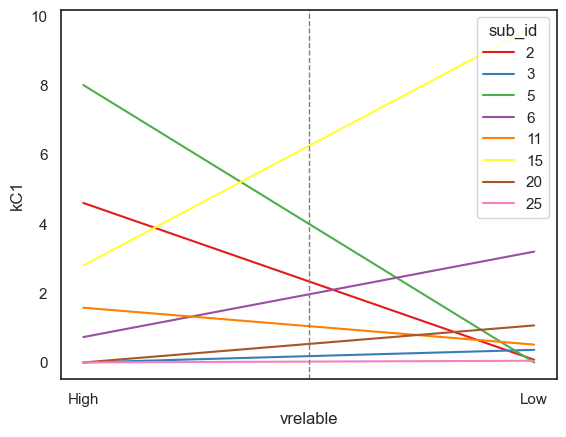

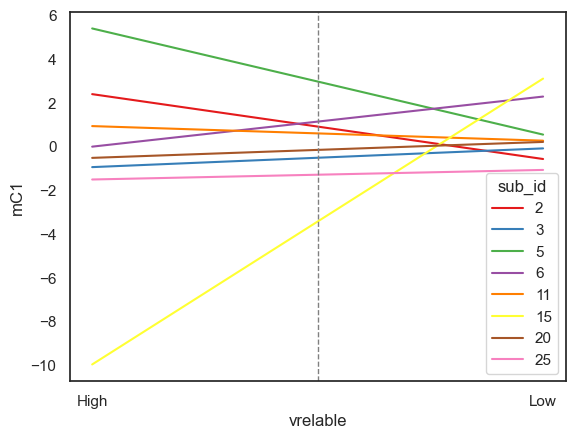

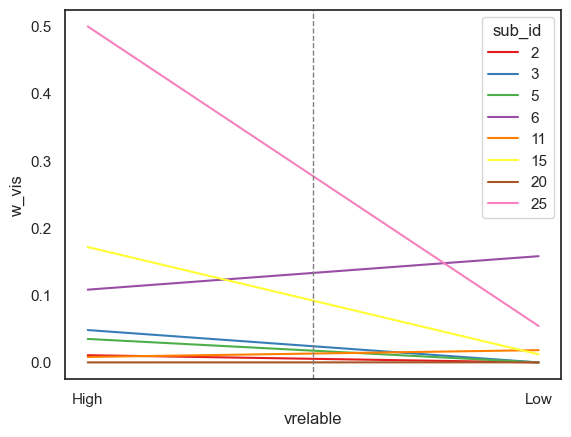

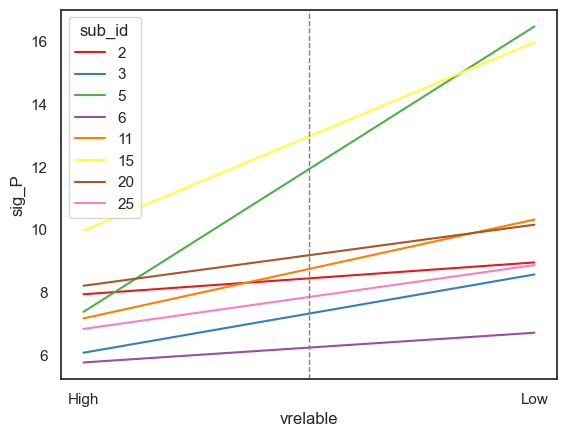

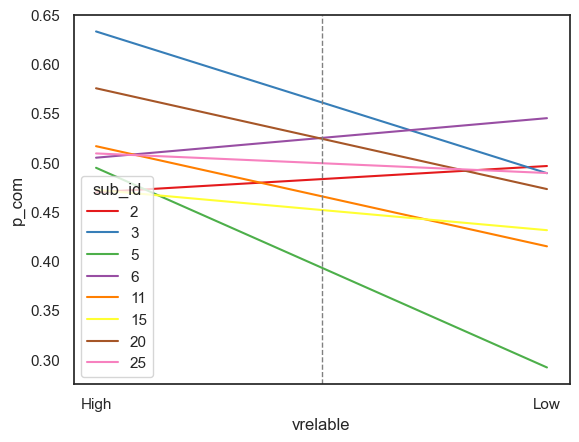

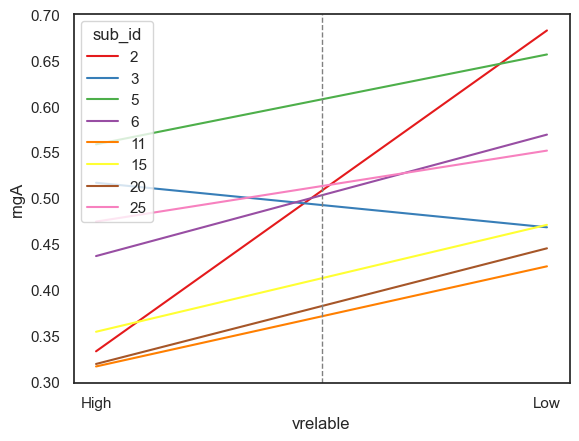

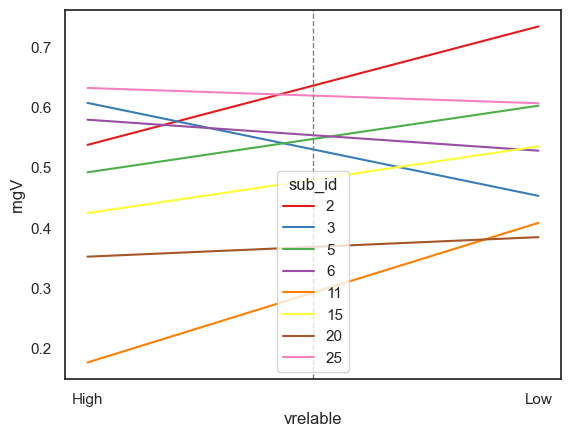

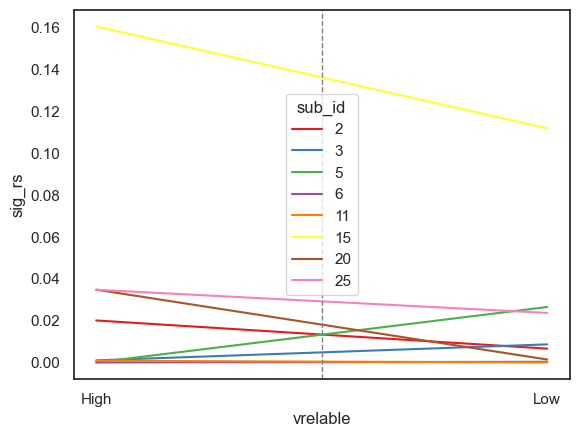

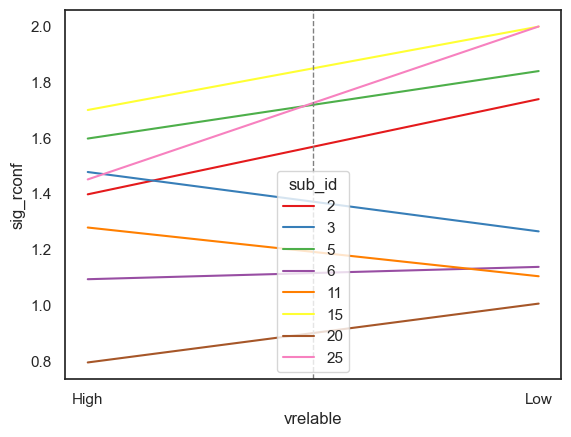

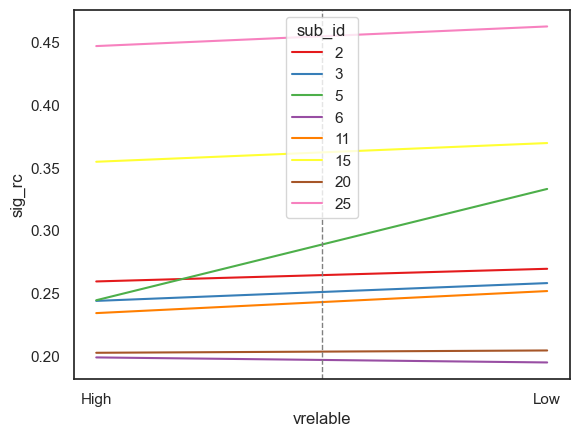

In [10]:
# each subject coded with different colors, high and low visual reliability with different shapes. 
# for each parameter
for idx in range(len(params_lst)):
    param_name = params_lst[idx]  # example for the first parameter
    sns.lineplot(data=df_best_params, x='vrelable', y=param_name, hue='sub_id', palette='Set1')
    plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1)
    plt.show()


### prediction

In [35]:
exp = Experiment(exp_name='split_data')
#model = ConfiModel(m_id=1, exp_config=exp.exp_config, vrel=vrel)

In [20]:
df_best_params.loc[(df_best_params.sub_id == 2) & (df_best_params.vrel == 1), params_lst].values.tolist()[0]

[1.4855382144451141,
 7.167923158034682,
 4.6017353532529075,
 2.3852498829364777,
 0.010981905514205723,
 7.933564689010382,
 0.469852364808321,
 0.33275787606835366,
 0.5378553200513124,
 0.02003512184003715,
 1.3971315239970332,
 0.25930969768371676]

In [36]:
def organize_dat(dat, remove_outliers:bool=False, sub_id=999):
        df = pd.DataFrame(dat)
        df.columns =['AudLoc', 'VisLoc', 'VisRel', 'blockType', 'RespLoc', 'CISize', 'Sources', 'ConfLevel']

        df['sub_id'] = sub_id
        df['delta_VA'] = df['VisLoc'] - df['AudLoc']
        df['VisRelLabel'] = df['VisRel'].map({1:'High', 2:'Low'})
        df['Modality'] = df['blockType'].map({0:'V', 1:'A'})

        def remove_outliers(df,bias_col='bias'):
            df = df.copy()
            df.loc[:,'bias_zscore'] = (df[bias_col] - df[bias_col].mean()) / df[bias_col].std()
            df.loc[:,'CISize_zscore'] = (df['CISize'] - df['CISize'].mean()) / df['CISize'].std()
            return df[(df.bias_zscore.abs() <= 3) & (df.CISize_zscore.abs() <= 3)]

        # get the perceptual bias for bi-modal congruent trials
        df_stat = df.loc[df['AudLoc'] == df['VisLoc']].groupby(['sub_id', 'blockType', 'VisRel', 'AudLoc'])['RespLoc'].agg(['mean', 'std']).reset_index()
        df = df.merge(df_stat, how='left', on=['sub_id', 'blockType', 'VisRel', 'AudLoc'])
        df['bias'] = df['RespLoc'] - df['mean']

        #flip bias
        df['flipBias'] = df['bias'].copy()
        df.loc[df['delta_VA']<0, 'flipBias'] = -df.loc[df['delta_VA']<0, 'flipBias']
        df['abs_delta_VA'] = df.delta_VA.abs()
        if remove_outliers:
            df = (df.groupby(['sub_id', 'Modality', 'VisRel', 'VisLoc', 'AudLoc'], group_keys=False)
                 .apply(remove_outliers)
                 .reset_index(drop=True))
        return df

In [37]:
def get_model_prediction(sub_id, vrel, nsim:int = 1000, remove_outliers = False, interimOutput:bool=False):
        """
        Load the fitted model results for a specific model and subject.

        Parameters:
        - model: Model object
        - sub_id: Subject identifier
        - fit_res_path: Path to the directory containing fitted results

        Returns:
        - DataFrame containing the fitted prediction for the specified model and subject.
        """
        model = ConfiModel(m_id=1, exp_config=exp.exp_config, vrel=vrel)
        par_input = df_best_params.loc[(df_best_params.sub_id == sub_id) & (df_best_params.vrel == vrel), params_lst].values.tolist()[0]

        trialConds = model.getCondRep(nIntSamples=nsim)
        
        dat_sim = model.run_simulation(inputs=par_input,trialConds=trialConds,interimOutput=interimOutput)
        df_sim = organize_dat(dat = dat_sim, remove_outliers = remove_outliers, sub_id=sub_id)

        # # remove outliers
        # if remove_outliers:
        #     df_sim['CISize_zscore'] = (df_sim['CISize'] - df_sim['CISize'].mean()) / df_sim['CISize'].std()
        #     df_sim = df_sim[df_sim.CISize_zscore.abs() < 3]  
        return df_sim

In [38]:
df_sim = []
# aggreagte all the subjects
for sub_id in sub_lst_all:
    for vrel in [1,2]:
        df_sim_t = get_model_prediction(sub_id = sub_id, vrel=vrel)
        df_sim_t['vrel'] = vrel
        df_sim.append(df_sim_t) 

df_sim = pd.concat(df_sim, ignore_index = True)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_18288\236948298.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_18288\236948298.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_18288\236948298.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This

In [39]:
df_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,Modality,mean,std,bias,flipBias,abs_delta_VA,bias_zscore,CISize_zscore,vrel
0,-10.0,-10.0,1.0,1.0,-9.659791,4.617280,1.0,77.0,2,0.0,High,A,-7.493481,2.913717,-2.166310,-2.166310,0.0,-0.743487,0.010308,1
1,-10.0,-10.0,1.0,1.0,-11.083949,2.028384,1.0,42.0,2,0.0,High,A,-7.493481,2.913717,-3.590468,-3.590468,0.0,-1.232264,-1.033119,1
2,-10.0,-10.0,1.0,1.0,-6.993848,3.730107,1.0,100.0,2,0.0,High,A,-7.493481,2.913717,0.499633,0.499633,0.0,0.171476,-0.347258,1
3,-10.0,-10.0,1.0,1.0,-9.085973,4.991607,1.0,41.0,2,0.0,High,A,-7.493481,2.913717,-1.592492,-1.592492,0.0,-0.546550,0.161176,1
4,-10.0,-10.0,1.0,1.0,-10.084941,4.213944,1.0,92.0,2,0.0,High,A,-7.493481,2.913717,-2.591460,-2.591460,0.0,-0.889400,-0.152252,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795086,10.0,10.0,2.0,0.0,1.275007,10.864238,1.0,100.0,25,0.0,Low,V,6.965375,4.283854,-5.690369,-5.690369,0.0,-1.328329,0.326067,2
795087,10.0,10.0,2.0,0.0,-2.800010,14.123077,2.0,7.0,25,0.0,Low,V,6.965375,4.283854,-9.765386,-9.765386,0.0,-2.279579,1.976846,2
795088,10.0,10.0,2.0,0.0,4.754386,12.793678,1.0,16.0,25,0.0,Low,V,6.965375,4.283854,-2.210989,-2.210989,0.0,-0.516122,1.303434,2
795089,10.0,10.0,2.0,0.0,4.273697,7.916625,1.0,100.0,25,0.0,Low,V,6.965375,4.283854,-2.691679,-2.691679,0.0,-0.628331,-1.167058,2


In [40]:
from utils.plot_function import *

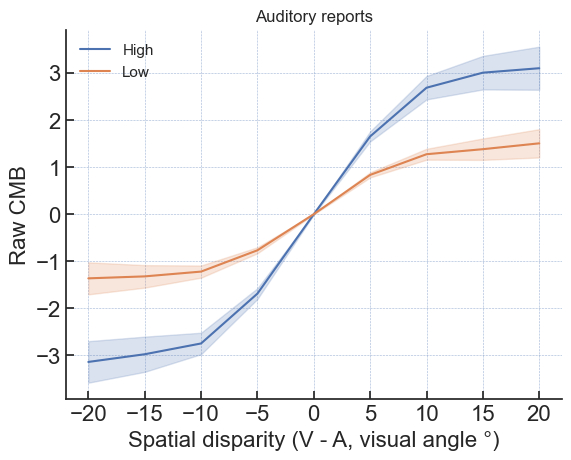

In [41]:
plot_VE(df_sim,  1)

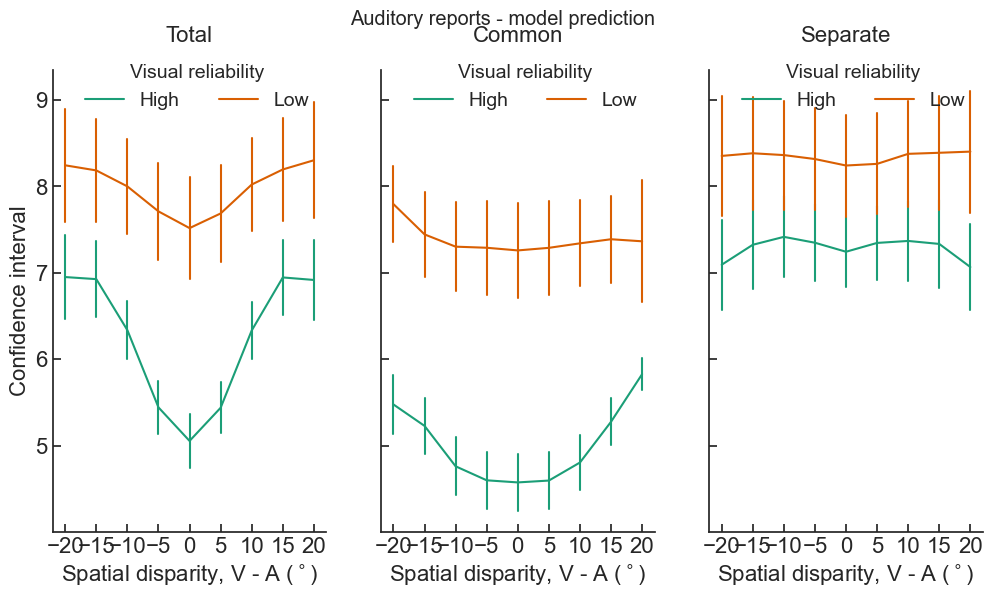

In [46]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
#plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_sim, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_sim, 'CISize', 'Common', axs[1],'A')
plot_group_pattern(df_sim, 'CISize', 'Separate', axs[2],'A')
axs[0].set_title('Total', loc='center', fontsize=16, pad=20)
axs[1].set_title('Common', loc='center', fontsize=16, pad=20)
axs[2].set_title('Separate', loc='center', fontsize=16, pad=20)
fig.suptitle('Auditory reports - model prediction')
plt.show()

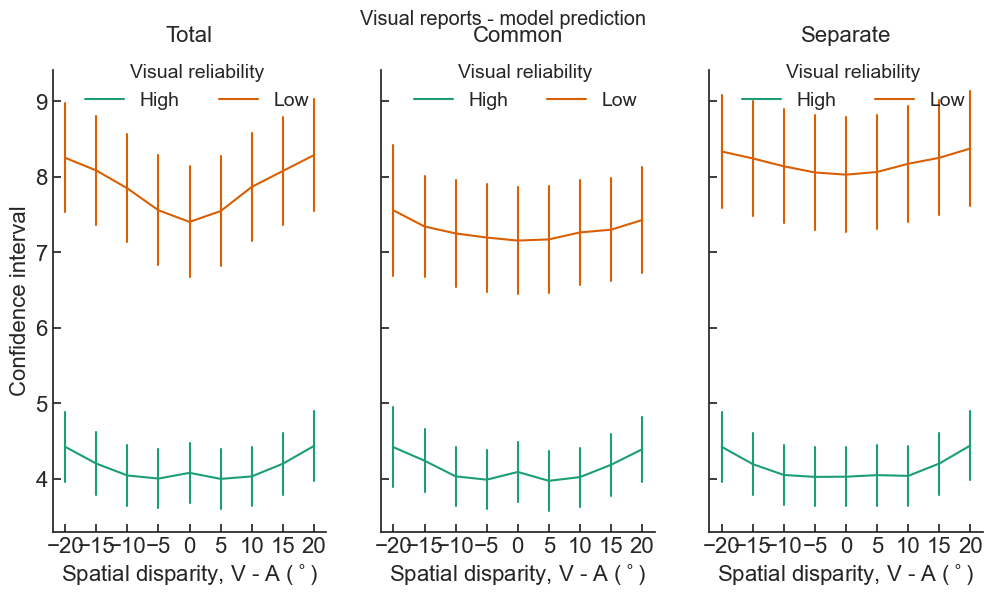

In [47]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
#plot_group_pattern(df_beh, 'CISize', 'Total', axs[0],'A')
plot_group_pattern(df_sim, 'CISize', 'Total', axs[0],'V')
plot_group_pattern(df_sim, 'CISize', 'Common', axs[1],'V')
plot_group_pattern(df_sim, 'CISize', 'Separate', axs[2],'V')
axs[0].set_title('Total', loc='center', fontsize=16, pad=20)
axs[1].set_title('Common', loc='center', fontsize=16, pad=20)
axs[2].set_title('Separate', loc='center', fontsize=16, pad=20)
fig.suptitle('Visual reports - model prediction')
plt.show()